# VIPER Model - Data Preparation & Exploratory Data Analysis

**Pipeline stage:** 1 of 6  
**Input:** `clinvar_vep_cadd_final.tsv`  
**Output:** `clinvar_features_engineered.tsv` + EDA figures (`eda_01_` → `eda_06_`)  

---

## Contents
1. [Imports & Data Loading](#1-imports--data-loading)
2. [Label Grouping](#2-label-grouping)
3. [Initial Data Audit](#3-initial-data-audit)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
   - 4.1 Class Distribution
   - 4.2 CADD PHRED Distribution
   - 4.3 Population Allele Frequency (MAX_AF)
   - 4.4 VEP IMPACT Distribution
   - 4.5 Top 10 Consequences by Class
   - 4.6 Correlation Heatmap
5. [Feature Engineering](#5-feature-engineering)
   - 5.1 Column Pruning
   - 5.2 SIFT & PolyPhen Parsing
   - 5.3 Missing Value Imputation
   - 5.4 Consequence Grouping
   - 5.5 Label Encoding
   - 5.6 Final Feature Matrix & Export

## 1. Imports & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Consistent color scheme used throughout
COLORS = {
    'Pathogenic': '#D7191C',
    'Benign':     '#2C7BB6',
    'VUS':        '#FDAE61'
}

df = pd.read_csv('/home/nayeema/Sysgen/VUS/clinvar_vep_cadd_final.tsv', sep='\t', low_memory=False)
df['Chrom'] = df['Chrom'].astype(str)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (104647, 29)

Dtypes:
Chrom                       object
Pos                          int64
ID                           int64
Ref                         object
Alt                         object
Consequence                 object
IMPACT                      object
SYMBOL                      object
Gene                        object
Feature                     object
BIOTYPE                     object
EXON                        object
INTRON                      object
HGVSc                       object
HGVSp                       object
VARIANT_CLASS               object
CANONICAL                   object
MANE_SELECT                 object
SIFT                        object
PolyPhen                    object
gnomADe_AF                 float64
gnomADg_AF                 float64
MAX_AF                     float64
CLIN_SIG                    object
variant_key                 object
RawScore                   float64
PHRED                      float64
Germline classification   

## 2. Label Grouping

ClinVar's raw `Germline classification` contains 30+ granular terms.  
We consolidate into three groups: **Pathogenic**, **Benign**, **VUS**.

In [5]:
patho_terms = [
    'Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic',
    'Pathogenic; drug response', 'Pathogenic/Likely pathogenic; risk factor',
    'Pathogenic/Likely pathogenic; other', 'Pathogenic/Likely pathogenic; association',
    'Pathogenic/Pathogenic, low penetrance; other',
    'Likely pathogenic; association',
    'Pathogenic/Likely pathogenic/Pathogenic, low penetrance'
]

benign_terms = [
    'Benign', 'Likely benign', 'Benign/Likely benign',
    'Benign; drug response', 'Benign/Likely benign; other',
    'Benign/Likely benign; association', 'Benign; association',
    'Likely benign; drug response; other', 'Likely benign; other',
    'Likely benign; association'
]

def group_label(x):
    if x in patho_terms:   return 'Pathogenic'
    elif x in benign_terms: return 'Benign'
    else:                   return 'VUS'

df['label_group'] = df['Germline classification'].apply(group_label)

print("Grouped distribution:")
print(df['label_group'].value_counts())
print(f"\nP:B ratio = 1:{df[df['label_group']=='Benign'].shape[0] / df[df['label_group']=='Pathogenic'].shape[0]:.2f}")

Grouped distribution:
label_group
VUS           40894
Benign        40175
Pathogenic    23578
Name: count, dtype: int64

P:B ratio = 1:1.70


## 3. Initial Data Audit

Check missingness, categorical cardinality, and chromosome coverage.

In [6]:
print("Missing values per column (sorted):")
print(df.isnull().sum().sort_values(ascending=False).to_string())
print(f"\nTotal variants: {len(df)}")

Missing values per column (sorted):
INTRON                     92472
gnomADg_AF                 74176
PolyPhen                   67944
SIFT                       65330
gnomADe_AF                 48654
MAX_AF                     44731
HGVSp                      19228
EXON                       18595
CLIN_SIG                    9990
HGVSc                       6561
MANE_SELECT                  854
SYMBOL                       152
CANONICAL                     77
RawScore                       8
PHRED                          8
IMPACT                         0
BIOTYPE                        0
Feature                        0
ID                             0
Ref                            0
Alt                            0
Consequence                    0
Pos                            0
Chrom                          0
Gene                           0
VARIANT_CLASS                  0
variant_key                    0
Germline classification        0
Germline review status         0
label_g

In [7]:
cat_cols = ['Consequence', 'IMPACT', 'BIOTYPE', 'VARIANT_CLASS', 'SIFT', 'PolyPhen']

for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().head(10))


Consequence (69 unique):
Consequence
missense_variant                                                            37699
synonymous_variant                                                          27102
frameshift_variant                                                          11061
stop_gained                                                                  5344
downstream_gene_variant                                                      4251
intron_variant                                                               3650
upstream_gene_variant                                                        2309
missense_variant&splice_region_variant                                       1680
splice_polypyrimidine_tract_variant&intron_variant                           1655
splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant     1649
Name: count, dtype: int64

IMPACT (4 unique):
IMPACT
MODERATE    40354
LOW         33040
HIGH        20517
MODIFIER    10736
Name: count, dtyp

In [8]:
# SIFT and PolyPhen broken into category + score for auditing
df['SIFT_cat']    = df['SIFT'].str.extract(r'^([a-z_]+)\(')
df['PolyPhen_cat'] = df['PolyPhen'].str.extract(r'^([a-z_]+)\(')

for col in ['SIFT_cat', 'PolyPhen_cat']:
    print(f"\n{col} by class:")
    print(df.groupby(['label_group', col]).size().unstack(fill_value=0))


SIFT_cat by class:
SIFT_cat     deleterious  deleterious_low_confidence  tolerated  \
label_group                                                       
Benign               680                         424       1083   
Pathogenic          1363                         721         71   
VUS                13103                        9920       8461   

SIFT_cat     tolerated_low_confidence  
label_group                            
Benign                            405  
Pathogenic                         20  
VUS                              3066  

PolyPhen_cat by class:
PolyPhen_cat  benign  possibly_damaging  probably_damaging  unknown
label_group                                                        
Benign          1662                324                373       81
Pathogenic       305                295               1249       15
VUS            16235               5920               9958      286


In [9]:
print("MAX_AF stats by class (before imputation):")
train_df = df[df['label_group'].isin(['Pathogenic', 'Benign'])].copy()
train_df['MAX_AF_filled'] = train_df['MAX_AF'].fillna(0)
print(train_df.groupby('label_group')['MAX_AF_filled'].describe())
print(f"\nMAX_AF = 0 in Benign:     {(train_df[train_df['label_group']=='Benign']['MAX_AF_filled']==0).sum()}")
print(f"MAX_AF = 0 in Pathogenic: {(train_df[train_df['label_group']=='Pathogenic']['MAX_AF_filled']==0).sum()}")

MAX_AF stats by class (before imputation):
               count      mean       std  min  25%       50%       75%     max
label_group                                                                   
Benign       40175.0  0.030489  0.119522  0.0  0.0  0.000024  0.000961  1.0000
Pathogenic   23578.0  0.000083  0.003360  0.0  0.0  0.000000  0.000000  0.4582

MAX_AF = 0 in Benign:     11192
MAX_AF = 0 in Pathogenic: 17741


In [10]:
impact_dist = df.groupby(['label_group', 'IMPACT']).size().unstack(fill_value=0)
print("IMPACT count by class:")
print(impact_dist)
print("\nIMPACT % by class:")
print((impact_dist.div(impact_dist.sum(axis=1), axis=0) * 100).round(1))

IMPACT count by class:
IMPACT        HIGH    LOW  MODERATE  MODIFIER
label_group                                  
Benign          67  31044      2711      6353
Pathogenic   19734    378      2217      1249
VUS            716   1618     35426      3134

IMPACT % by class:
IMPACT       HIGH   LOW  MODERATE  MODIFIER
label_group                                
Benign        0.2  77.3       6.7      15.8
Pathogenic   83.7   1.6       9.4       5.3
VUS           1.8   4.0      86.6       7.7


In [11]:
for group in ['Benign', 'Pathogenic', 'VUS']:
    print(f"\nTop 10 Consequences — {group}:")
    print(df[df['label_group']==group]['Consequence'].value_counts().head(10))


Top 10 Consequences — Benign:
Consequence
synonymous_variant                                                          27041
intron_variant                                                               3556
missense_variant                                                             2528
downstream_gene_variant                                                      1682
splice_polypyrimidine_tract_variant&intron_variant                           1576
splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant     1216
upstream_gene_variant                                                         822
splice_region_variant&synonymous_variant                                      572
splice_region_variant&intron_variant                                          305
splice_donor_region_variant&intron_variant                                    194
Name: count, dtype: int64

Top 10 Consequences — Pathogenic:
Consequence
frameshift_variant                          10834
stop_gained   

In [12]:
for group in ['Benign', 'Pathogenic', 'VUS']:
    print(f"\nBIOTYPE — {group}:")
    print(df[df['label_group']==group]['BIOTYPE'].value_counts())


BIOTYPE — Benign:
BIOTYPE
protein_coding                        39828
lncRNA                                  122
misc_RNA                                 96
snRNA                                    63
nonsense_mediated_decay                  26
miRNA                                    21
snoRNA                                    4
transcribed_processed_pseudogene          3
unprocessed_pseudogene                    3
processed_pseudogene                      3
protein_coding_CDS_not_defined            2
transcribed_unprocessed_pseudogene        2
protein_coding_LoF                        1
rRNA_pseudogene                           1
Name: count, dtype: int64

BIOTYPE — Pathogenic:
BIOTYPE
protein_coding             23327
lncRNA                       157
misc_RNA                      62
snRNA                         22
nonsense_mediated_decay        5
miRNA                          2
processed_pseudogene           2
protein_coding_LoF             1
Name: count, dtype: int64

BIOTYPE —

## 4. Exploratory Data Analysis


### 4.1 Class Distribution  
`→ saves: eda_01_class_distribution.png`

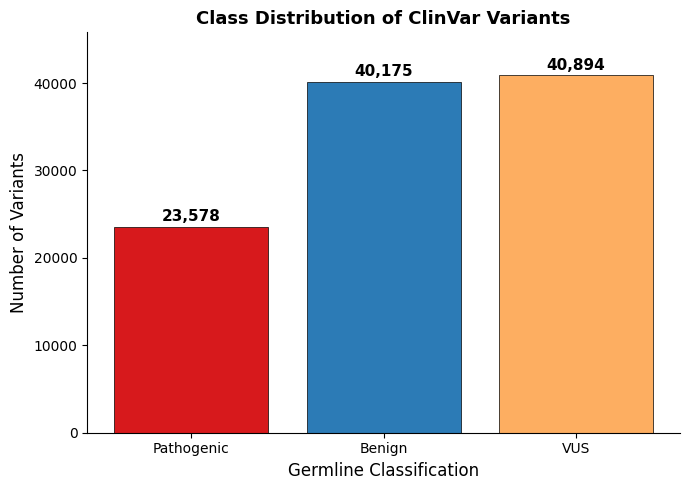

Saved: eda_01_class_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['label_group'].value_counts()[['Pathogenic', 'Benign', 'VUS']]
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[c] for c in counts.index], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Germline Classification', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('Class Distribution of ClinVar Variants', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150)
plt.show()
print('Saved: eda_01_class_distribution.png')

### 4.2 CADD PHRED Distribution  
`→ saves: eda_02_phred_distribution.png`

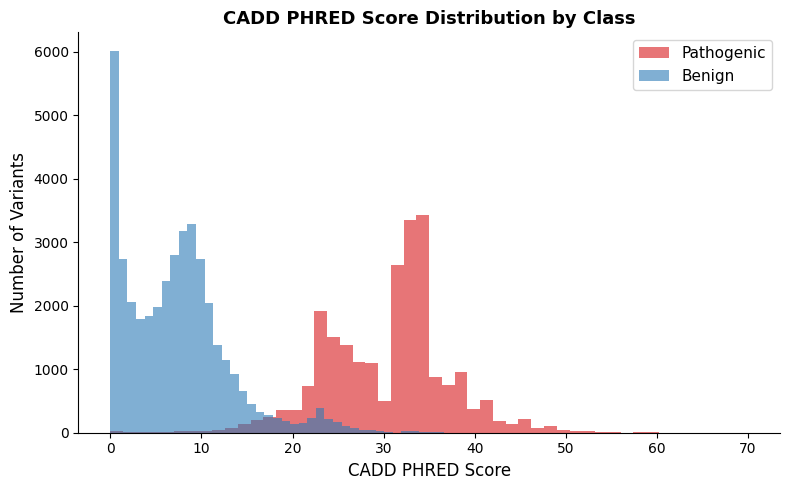

Saved: eda_02_phred_distribution.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for label in ['Pathogenic', 'Benign']:
    subset = df[df['label_group'] == label]['PHRED'].dropna()
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=COLORS[label], edgecolor='none')
ax.set_xlabel('CADD PHRED Score', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('CADD PHRED Score Distribution by Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_02_phred_distribution.png', dpi=150)
plt.show()
print('Saved: eda_02_phred_distribution.png')

### 4.3 Population Allele Frequency (MAX_AF, log scale)  
`→ saves: eda_03_maxaf_distribution.png`

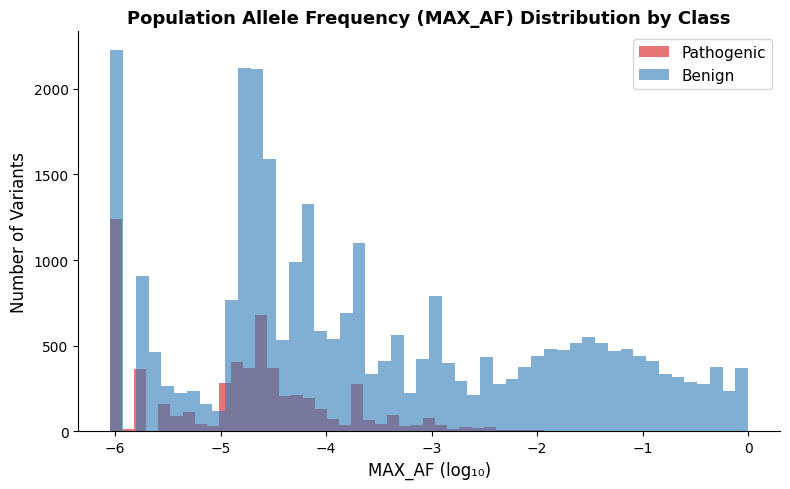

Saved: eda_03_maxaf_distribution.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
for label in ['Pathogenic', 'Benign']:
    subset = df[df['label_group'] == label]['MAX_AF'].fillna(0)
    subset = subset[subset > 0]
    ax.hist(np.log10(subset + 1e-10), bins=50, alpha=0.6,
            label=label, color=COLORS[label], edgecolor='none')
ax.set_xlabel('MAX_AF (log₁₀)', fontsize=12)
ax.set_ylabel('Number of Variants', fontsize=12)
ax.set_title('Population Allele Frequency (MAX_AF) Distribution by Class',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_03_maxaf_distribution.png', dpi=150)
plt.show()
print('Saved: eda_03_maxaf_distribution.png')

### 4.4 VEP IMPACT Distribution by Class  
`→ saves: eda_04_impact_distribution.png`

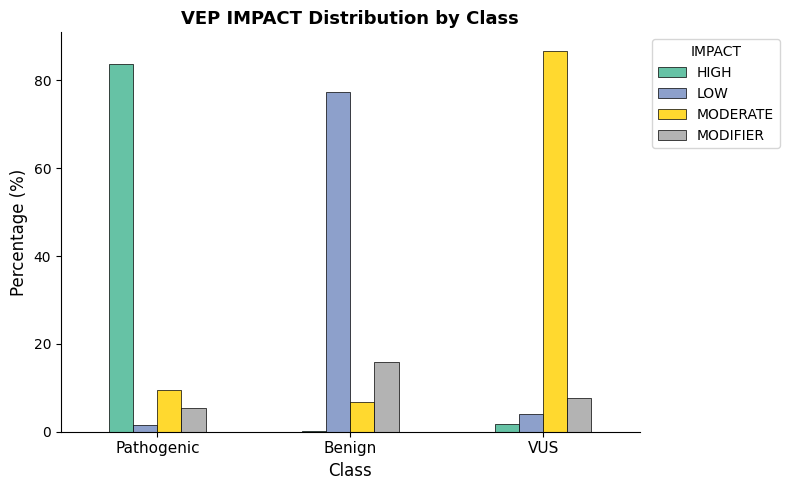

Saved: eda_04_impact_distribution.png


In [16]:
impact_pct = df.groupby(['label_group', 'IMPACT']).size().unstack(fill_value=0)
impact_pct = impact_pct.div(impact_pct.sum(axis=1), axis=0) * 100
impact_pct = impact_pct.loc[['Pathogenic', 'Benign', 'VUS']]

fig, ax = plt.subplots(figsize=(8, 5))
impact_pct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('VEP IMPACT Distribution by Class', fontsize=13, fontweight='bold')
ax.legend(title='IMPACT', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_xticklabels(impact_pct.index, rotation=0, fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('eda_04_impact_distribution.png', dpi=150)
plt.show()
print('Saved: eda_04_impact_distribution.png')

### 4.5 Top 10 Consequences by Class  
`→ saves: eda_05_consequence_distribution.png`

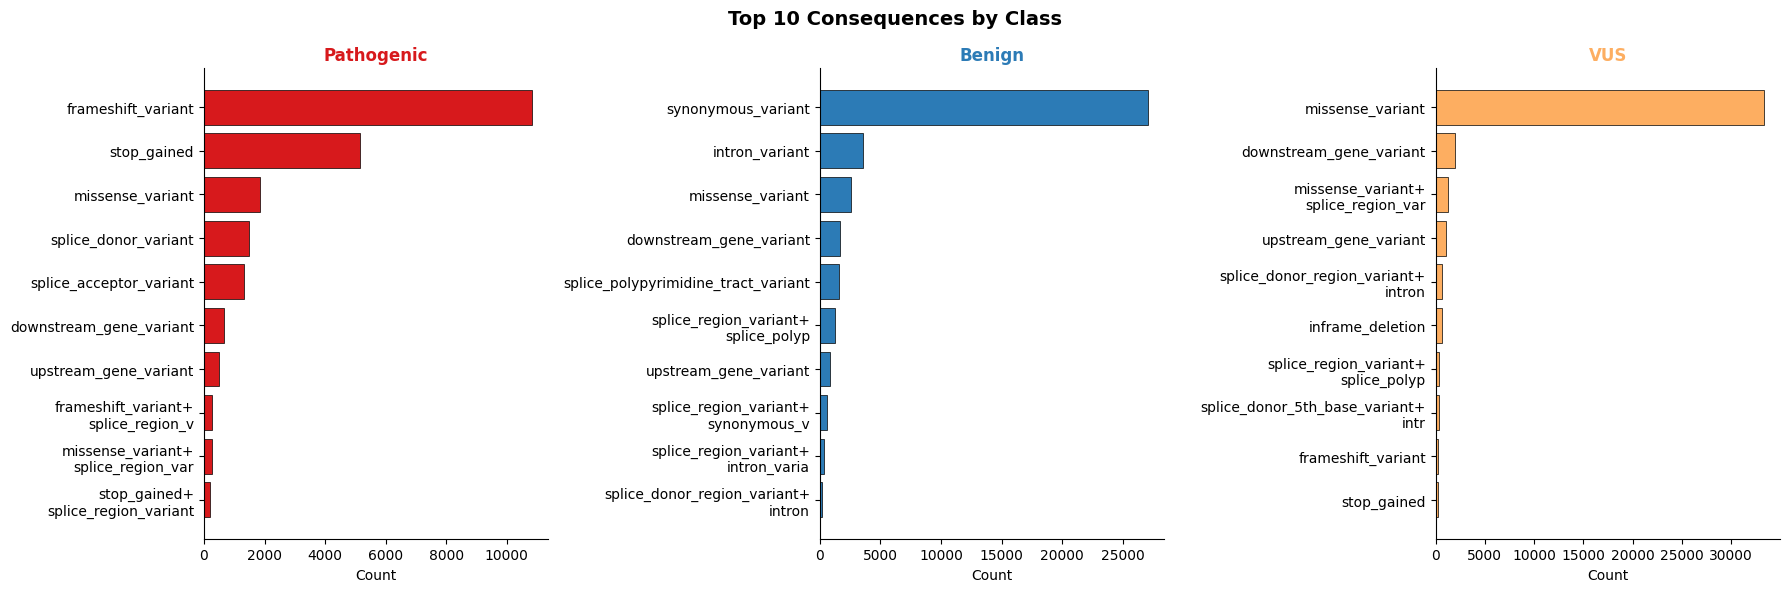

Saved: eda_05_consequence_distribution.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, group in zip(axes, ['Pathogenic', 'Benign', 'VUS']):
    top10 = df[df['label_group'] == group]['Consequence'].value_counts().head(10)
    top10.index = [c.replace('&', '+\n')[:35] for c in top10.index]
    ax.barh(top10.index[::-1], top10.values[::-1],
            color=COLORS[group], edgecolor='black', linewidth=0.5)
    ax.set_title(group, fontsize=12, fontweight='bold', color=COLORS[group])
    ax.set_xlabel('Count', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Top 10 Consequences by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_consequence_distribution.png', dpi=150)
plt.show()
print('Saved: eda_05_consequence_distribution.png')

### 4.6 Correlation Heatmap (Numerical Features)  
`→ saves: eda_06_correlation.png`

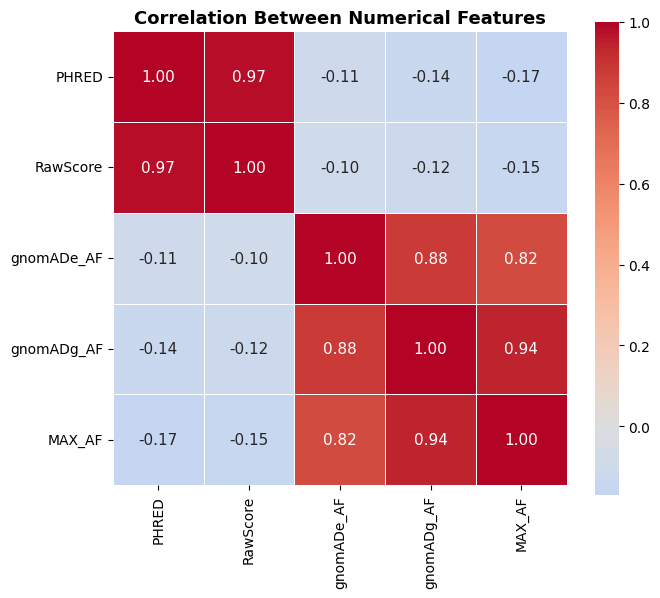

Saved: eda_06_correlation.png


In [18]:
num_cols = ['PHRED', 'RawScore', 'gnomADe_AF', 'gnomADg_AF', 'MAX_AF']
corr_df = df[num_cols].fillna(0).corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Correlation Between Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_correlation.png', dpi=150)
plt.show()
print('Saved: eda_06_correlation.png')

## 5. Feature Engineering

Transform the raw dataset into an ML-ready feature matrix.

### 5.1 Column Pruning

Columns removed and rationale:
| Column | Reason |
|---|---|
| `RawScore` | Highly correlated with `PHRED` |
| `gnomADe_AF`, `gnomADg_AF` | Correlated with `MAX_AF` (kept as summary) |
| `INTRON`, `EXON` | Positional metadata, not an ML feature |
| `HGVSc`, `HGVSp` | Nomenclature strings |
| `CLIN_SIG` | Superseded by `Germline classification` |
| `MANE_SELECT`, `CANONICAL`, `Feature` | Transcript metadata |
| `SYMBOL` | Gene name (kept via `Gene` column) |
| `variant_key` | Row identifier |
| `Germline review status` | Used for filtering only |

In [19]:
drop_cols = [
    'RawScore', 'gnomADe_AF', 'gnomADg_AF',
    'INTRON', 'EXON', 'HGVSc', 'HGVSp',
    'CLIN_SIG', 'MANE_SELECT', 'CANONICAL',
    'Feature', 'SYMBOL', 'variant_key',
    'Germline review status'
]

df = df.drop(columns=drop_cols)
print(f"Shape after pruning: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape after pruning: (104647, 18)
Remaining columns: ['Chrom', 'Pos', 'ID', 'Ref', 'Alt', 'Consequence', 'IMPACT', 'Gene', 'BIOTYPE', 'VARIANT_CLASS', 'SIFT', 'PolyPhen', 'MAX_AF', 'PHRED', 'Germline classification', 'label_group', 'SIFT_cat', 'PolyPhen_cat']


### 5.2 SIFT & PolyPhen Parsing

Split compound strings (e.g. `deleterious(0.02)`) into separate **category** and **score** columns.

In [20]:
df['SIFT_cat']      = df['SIFT'].str.extract(r'^([a-z_]+)\(')
df['SIFT_score']    = df['SIFT'].str.extract(r'\(([0-9.]+)\)').astype(float)
df['PolyPhen_cat']  = df['PolyPhen'].str.extract(r'^([a-z_]+)\(')
df['PolyPhen_score'] = df['PolyPhen'].str.extract(r'\(([0-9.]+)\)').astype(float)
df = df.drop(columns=['SIFT', 'PolyPhen'])

print('SIFT_cat unique:',    df['SIFT_cat'].unique())
print('PolyPhen_cat unique:', df['PolyPhen_cat'].unique())
print(f'\nSIFT_score missing:    {df["SIFT_score"].isna().sum()}')
print(f'PolyPhen_score missing: {df["PolyPhen_score"].isna().sum()}')

SIFT_cat unique: [nan 'tolerated_low_confidence' 'deleterious_low_confidence' 'tolerated'
 'deleterious']
PolyPhen_cat unique: [nan 'benign' 'possibly_damaging' 'probably_damaging' 'unknown']

SIFT_score missing:    65330
PolyPhen_score missing: 67944


### 5.3 Missing Value Imputation

| Feature | Strategy | Rationale |
|---|---|---|
| `SIFT_cat`, `PolyPhen_cat` | Fill → `'missing'` | Preserve absence as informative |
| `SIFT_score`, `PolyPhen_score` | Fill → `-1` | Sentinel outside valid [0,1] range |
| `MAX_AF` | Fill → `0` | Not in gnomAD = ultra-rare |
| `PHRED` | Drop rows (n=8) | Too few to impute reliably |
| `BIOTYPE` | Group non-coding → `'other'` | Reduce cardinality |

In [21]:
df['SIFT_cat']      = df['SIFT_cat'].fillna('missing')
df['PolyPhen_cat']  = df['PolyPhen_cat'].fillna('missing')
df['SIFT_score']    = df['SIFT_score'].fillna(-1)
df['PolyPhen_score'] = df['PolyPhen_score'].fillna(-1)
df['MAX_AF']        = df['MAX_AF'].fillna(0)
df = df.dropna(subset=['PHRED'])
df['BIOTYPE'] = df['BIOTYPE'].apply(lambda x: x if x == 'protein_coding' else 'other')

print(f'Shape after imputation: {df.shape}')
print(f'\nMissing values remaining:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Shape after imputation: (104639, 18)

Missing values remaining:
Series([], dtype: int64)


### 5.4 Consequence Grouping

Reduce 69 VEP consequence terms to 10 biologically meaningful categories.

In [22]:
def group_consequence(c):
    c = str(c).lower()
    if 'frameshift' in c:                                        return 'frameshift'
    elif 'stop_gained' in c or 'stop_lost' in c:                return 'stop_variant'
    elif 'splice_donor' in c or 'splice_acceptor' in c:         return 'canonical_splice'
    elif any(x in c for x in ['splice_region', 'splice_polypyrimidine', 'splice_donor_5th']):
                                                                  return 'splice_region'
    elif 'missense' in c:                                        return 'missense'
    elif 'synonymous' in c:                                      return 'synonymous'
    elif 'inframe' in c:                                         return 'inframe_indel'
    elif 'upstream' in c or 'downstream' in c:                  return 'regulatory'
    elif 'intron' in c:                                          return 'intronic'
    elif 'utr' in c:                                             return 'UTR'
    else:                                                        return 'other'

df['Consequence_grouped'] = df['Consequence'].apply(group_consequence)
print('Consequence groups:')
print(df['Consequence_grouped'].value_counts())

Consequence groups:
Consequence_grouped
missense            37713
synonymous          27104
frameshift          11501
regulatory           6552
splice_region        6117
stop_variant         5607
canonical_splice     4805
intronic             3746
inframe_indel         910
UTR                   417
other                 167
Name: count, dtype: int64


### 5.5 Label Encoding

In [23]:
cat_cols = ['IMPACT', 'VARIANT_CLASS', 'BIOTYPE',
            'SIFT_cat', 'PolyPhen_cat', 'Consequence_grouped']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

IMPACT: {'HIGH': np.int64(0), 'LOW': np.int64(1), 'MODERATE': np.int64(2), 'MODIFIER': np.int64(3)}
VARIANT_CLASS: {'SNV': np.int64(0), 'deletion': np.int64(1), 'indel': np.int64(2), 'insertion': np.int64(3), 'substitution': np.int64(4)}
BIOTYPE: {'other': np.int64(0), 'protein_coding': np.int64(1)}
SIFT_cat: {'deleterious': np.int64(0), 'deleterious_low_confidence': np.int64(1), 'missing': np.int64(2), 'tolerated': np.int64(3), 'tolerated_low_confidence': np.int64(4)}
PolyPhen_cat: {'benign': np.int64(0), 'missing': np.int64(1), 'possibly_damaging': np.int64(2), 'probably_damaging': np.int64(3), 'unknown': np.int64(4)}
Consequence_grouped: {'UTR': np.int64(0), 'canonical_splice': np.int64(1), 'frameshift': np.int64(2), 'inframe_indel': np.int64(3), 'intronic': np.int64(4), 'missense': np.int64(5), 'other': np.int64(6), 'regulatory': np.int64(7), 'splice_region': np.int64(8), 'stop_variant': np.int64(9), 'synonymous': np.int64(10)}


### 5.6 Final Feature Matrix & Export

In [24]:
feature_cols = [
    'PHRED',
    'MAX_AF',
    'SIFT_score',
    'PolyPhen_score',
    'IMPACT_encoded',
    'VARIANT_CLASS_encoded',
    'BIOTYPE_encoded',
    'SIFT_cat_encoded',
    'PolyPhen_cat_encoded',
    'Consequence_grouped_encoded'
]

print('Final feature set:')
for f in feature_cols:
    print(f'  {f}: {df[f].dtype} | min={df[f].min():.3f} | max={df[f].max():.3f}')

print(f'\nFinal dataset shape: {df.shape}')
print(f'Feature matrix shape: {df[feature_cols].shape}')
print(f'\nLabel distribution:')
print(df["label_group"].value_counts())

df.to_csv('clinvar_features_engineered.tsv', sep='\t', index=False)
print('\nSaved: clinvar_features_engineered.tsv')

Final feature set:
  PHRED: float64 | min=0.001 | max=70.000
  MAX_AF: float64 | min=0.000 | max=1.000
  SIFT_score: float64 | min=-1.000 | max=1.000
  PolyPhen_score: float64 | min=-1.000 | max=1.000
  IMPACT_encoded: int64 | min=0.000 | max=3.000
  VARIANT_CLASS_encoded: int64 | min=0.000 | max=4.000
  BIOTYPE_encoded: int64 | min=0.000 | max=1.000
  SIFT_cat_encoded: int64 | min=0.000 | max=4.000
  PolyPhen_cat_encoded: int64 | min=0.000 | max=4.000
  Consequence_grouped_encoded: int64 | min=0.000 | max=10.000

Final dataset shape: (104639, 25)
Feature matrix shape: (104639, 10)

Label distribution:
label_group
VUS           40894
Benign        40169
Pathogenic    23576
Name: count, dtype: int64

Saved: clinvar_features_engineered.tsv
